In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
df.head()

Shape: (7043, 21)

Columns:
 ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Shape and data types
print("Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nTarget Distribution:")
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True).round(3) * 100)

Shape: (7043, 21)

Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            

In [5]:
# Fix TotalCharges - convert to numeric, spaces become NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check how many NaN appeared
print("NaN in TotalCharges after fix:", df['TotalCharges'].isnull().sum())

# Check those rows
print(df[df['TotalCharges'].isnull()][['tenure', 'MonthlyCharges', 'TotalCharges']])

NaN in TotalCharges after fix: 11
      tenure  MonthlyCharges  TotalCharges
488        0           52.55           NaN
753        0           20.25           NaN
936        0           80.85           NaN
1082       0           25.75           NaN
1340       0           56.05           NaN
3331       0           19.85           NaN
3826       0           25.35           NaN
4380       0           20.00           NaN
5218       0           19.70           NaN
6670       0           73.35           NaN
6754       0           61.90           NaN


In [6]:
# Fill TotalCharges NaN with 0 (new customers, not yet billed)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Convert Churn to binary 0/1
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Drop customerID - not useful for ML
df = df.drop(columns=['customerID'])

# Confirm fixes
print("TotalCharges NaN remaining:", df['TotalCharges'].isnull().sum())
print("Churn unique values:", df['Churn'].unique())
print("Shape after cleanup:", df.shape)

TotalCharges NaN remaining: 0
Churn unique values: [0 1]
Shape after cleanup: (7043, 20)


Numeric: ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


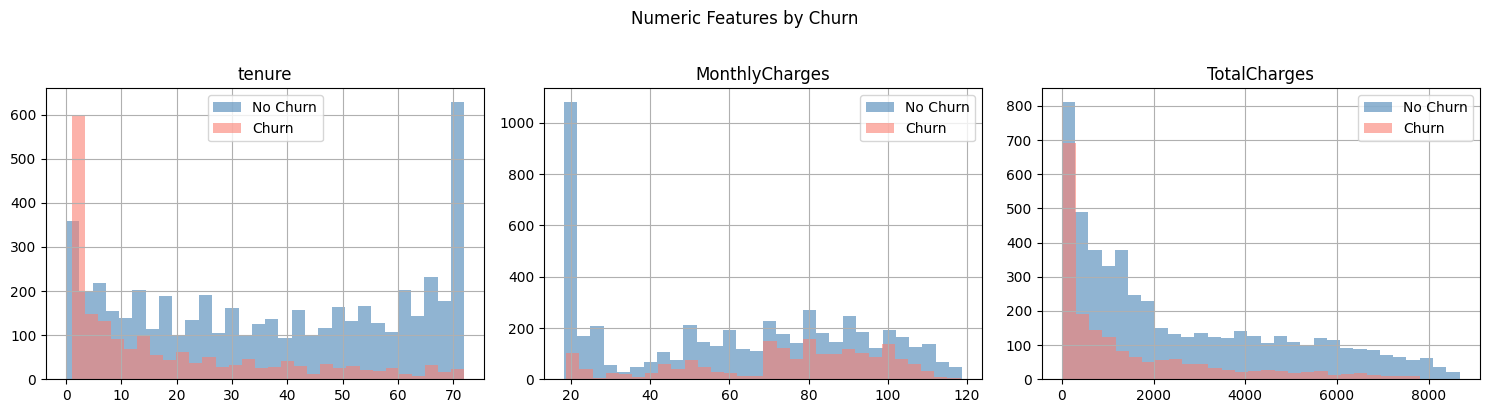

In [7]:
# Separate numeric and categorical columns
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_cols = df.drop(columns=numeric_cols + ['Churn', 'SeniorCitizen']).columns.tolist()

print("Numeric:", numeric_cols)
print("Categorical:", categorical_cols)

# Plot numeric distributions by churn
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(numeric_cols):
    df[df['Churn']==0][col].hist(ax=axes[i], alpha=0.6, label='No Churn', bins=30, color='steelblue')
    df[df['Churn']==1][col].hist(ax=axes[i], alpha=0.6, label='Churn', bins=30, color='salmon')
    axes[i].set_title(col)
    axes[i].legend()
plt.suptitle('Numeric Features by Churn', y=1.02)
plt.tight_layout()
plt.show()


IndexError: index 12 is out of bounds for axis 0 with size 12

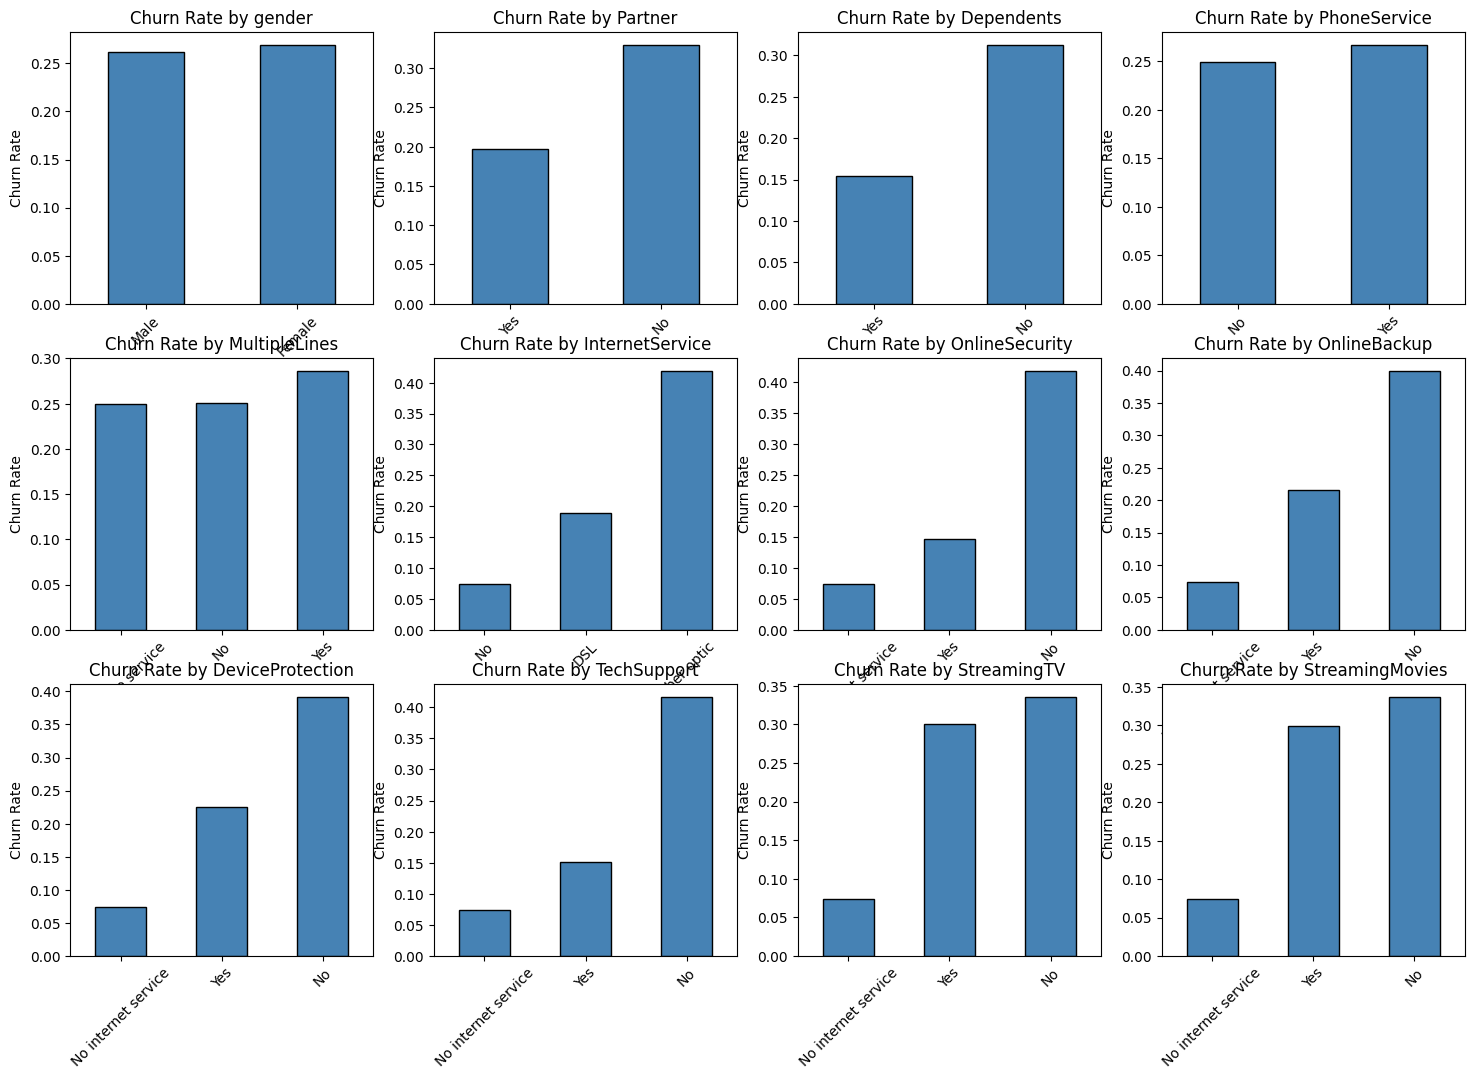

In [8]:
# Churn rate by key categorical features
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    churn_rate = df.groupby(col)['Churn'].mean().sort_values()
    churn_rate.plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='black')
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_ylabel('Churn Rate')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

# Hide empty subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Churn Rate by Categorical Features', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

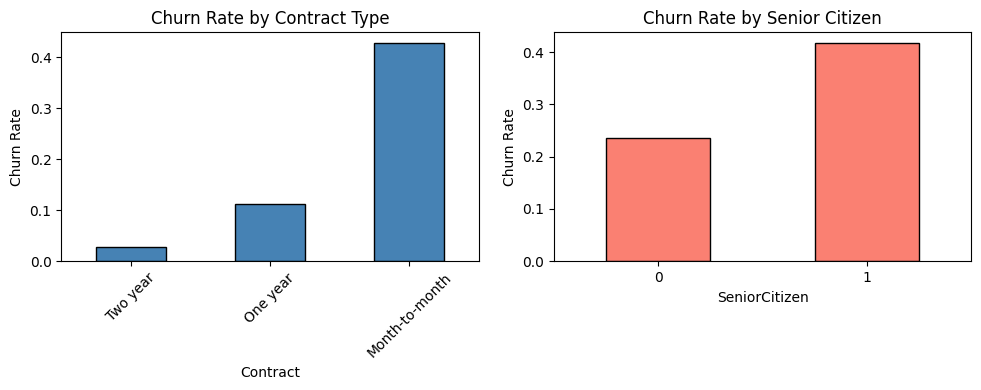

In [9]:
# Contract + SeniorCitizen churn rates
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

df.groupby('Contract')['Churn'].mean().sort_values().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Churn Rate by Contract Type')
axes[0].set_ylabel('Churn Rate')
axes[0].tick_params(axis='x', rotation=45)

df.groupby('SeniorCitizen')['Churn'].mean().plot(
    kind='bar', ax=axes[1], color='salmon', edgecolor='black')
axes[1].set_title('Churn Rate by Senior Citizen')
axes[1].set_ylabel('Churn Rate')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [10]:
import os
os.makedirs('../data/processed', exist_ok=True)
df.to_csv('../data/processed/churn_cleaned.csv', index=False)
print("Saved cleaned data. Shape:", df.shape)

Saved cleaned data. Shape: (7043, 20)
